# Phase 2 EDA — Goodreads Children Dataset

**Mục tiêu:** Thu thập số liệu để chốt 5 quyết định trước Phase 3.

| # | Quyết định | Section |
|---|-----------|---------|
| 1 | Dùng **implicit hay hybrid**? | Rating Distribution |
| 2 | Có **filter user** không? Ngưỡng bao nhiêu? | User Activity |
| 3 | Có **filter item** không? Ngưỡng bao nhiêu? | Item Popularity |
| 4 | Có dùng **time-based split** không? | Time Distribution |
| 5 | **Genres top-k** = 3 hay 5? | Genres Distribution |

---
> **Pipeline:** `Phase 1 (DONE) → Phase 2: EDA (NOW) → Phase 3: Filtering + Feature Eng → Phase 4: LightFM`

In [10]:
from pathlib import Path
from collections import Counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ────────────────────────────────────────────────────────────────
DATA_DIR = Path.cwd()
INTERACTIONS_PATH = DATA_DIR / 'goodreads_interactions_poetry.json'
BOOKS_PATH        = DATA_DIR / 'goodreads_books_poetry.json'

# ── Scan limits (None = full scan) ───────────────────────────────────────
MAX_INTERACTION_LINES = None
MAX_BOOK_LINES        = None

# ── Deduplication ────────────────────────────────────────────────────────
DEDUP_INTERACTIONS = True
DEDUP_KEYS = ('user_id', 'book_id')

# ── Threshold mode ───────────────────────────────────────────────────────
# 'date_added' : implicit — any record that has a date_added (recommended)
# 'explicit'   : only records with rating in [1, 5]
# 'all'        : every deduped record
THRESHOLD_MODE    = 'date_added'
EXPLICIT_MIN_RATING = 1
EXPLICIT_MAX_RATING = 5

# ── Time filter ──────────────────────────────────────────────────────────
DATE_FORMAT          = '%a %b %d %H:%M:%S %z %Y'
APPLY_MIN_YEAR_FILTER = True
MIN_INTERACTION_YEAR  = 2007

# ── Genres ───────────────────────────────────────────────────────────────
# Shelves to EXCLUDE when extracting genres from popular_shelves
NON_GENRE_SHELVES = {
    'to-read', 'currently-reading', 'read', 'owned', 'favorites',
    'books-i-own', 'wish-list', 'abandoned', 'did-not-finish',
    'dnf', 're-read', 'default', 'owned-books', 'library',
    'english', 'audio', 'audiobook', 'ebook', 'kindle',
}
GENRES_TOP_K_CANDIDATES = [3, 5, 10]   # candidates to evaluate

# ── Output ───────────────────────────────────────────────────────────────
WRITE_FILTERED_FILE = True
OUTPUT_DIR = DATA_DIR / 'eda_outputs'
HIST_DIR   = OUTPUT_DIR / 'histograms'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HIST_DIR.mkdir(parents=True, exist_ok=True)

print('Config loaded.')
print(f'  INTERACTIONS : {INTERACTIONS_PATH}')
print(f'  BOOKS        : {BOOKS_PATH}')
print(f'  THRESHOLD_MODE : {THRESHOLD_MODE}')
print(f'  MIN_YEAR_FILTER: {MIN_INTERACTION_YEAR if APPLY_MIN_YEAR_FILTER else "OFF"}')

Config loaded.
  INTERACTIONS : d:\NAM3_UIT\HK2\MXH\Data\goodreads_interactions_poetry.json
  BOOKS        : d:\NAM3_UIT\HK2\MXH\Data\goodreads_books_poetry.json
  THRESHOLD_MODE : date_added
  MIN_YEAR_FILTER: 2007


In [13]:
def file_overview(path: Path):
    if not path.exists():
        return {'file': path.name, 'exists': False, 'size_gb': None}
    size_gb = path.stat().st_size / (1024 ** 3)
    return {'file': path.name, 'exists': True, 'size_gb': round(size_gb, 3)}

display(pd.DataFrame([
    file_overview(INTERACTIONS_PATH),
    file_overview(BOOKS_PATH),
]))

,file,exists,size_gb
0,goodreads_interactions_poetry.json,True,0.8610
1,goodreads_books_poetry.json,True,0.1200


In [ ]:

def preview_jsonl(path: Path, n: int = 3) -> pd.DataFrame:
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f, 1):
            if i > n: break
            line = line.strip()
            if line:
                try: rows.append(json.loads(line))
                except json.JSONDecodeError: pass
    return pd.json_normalize(rows) if rows else pd.DataFrame()

print('── Interactions sample (3 rows) ──')
display(preview_jsonl(INTERACTIONS_PATH, 3))
print('── Books sample (3 rows) ──')
display(preview_jsonl(BOOKS_PATH, 3))

── Interactions sample (3 rows) ──


,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,1384,1bad0122cebb4aa9213f9fe1aa281f66,True,4,,Wed May 09 09:33:44 -0700 2007,Wed May 09 09:33:44 -0700 2007,,
1,8842281e1d1347389f2ab93d60773d4d,1376,eb6e502d0c04d57b43a5a02c21b64ab4,True,4,,Wed May 09 09:33:18 -0700 2007,Wed May 09 09:33:18 -0700 2007,,
2,8842281e1d1347389f2ab93d60773d4d,30119,787564bef16cb1f43e0f641ab59d25b7,True,5,,Sat Jan 13 13:44:20 -0800 2007,Wed Mar 22 11:45:08 -0700 2017,Tue Mar 01 00:00:00 -0800 1983,


── Books sample (3 rows) ──


,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,,1,[],US,eng,"[{'count': '8', 'name': 'to-read'}, {'count': ...",,false,3.83,,[],Number 30 in a series of literary pamphlets pu...,Paperback,https://www.goodreads.com/book/show/16037549-v...,"[{'author_id': '15585', 'role': ''}]","Houghton, Mifflin and Company",80,1,,11,,1887,https://www.goodreads.com/book/show/16037549-v...,https://images.gr-assets.com/books/1348176637m...,16037549,3,5212748,Vision of Sir Launfal and Other Poems,Vision of Sir Launfal and Other Poems
1,0811223981,2,[],US,,"[{'count': '100', 'name': 'to-read'}, {'count'...",,false,3.83,B00U2WY9U8,[],Fairy Tales gathers the unconventional verse d...,Paperback,https://www.goodreads.com/book/show/22466716-f...,"[{'author_id': '16073', 'role': ''}, {'author_...",New Directions,128,20,9780811223980,4,,2015,https://www.goodreads.com/book/show/22466716-f...,https://images.gr-assets.com/books/1404958407m...,22466716,37,41905435,Fairy Tales: Dramolettes,Fairy Tales: Dramolettes
2,0374428115,7,[],US,,"[{'count': '32', 'name': 'to-read'}, {'count':...",,false,4.38,,[],Three poems describe the nighttime adventures ...,Paperback,https://www.goodreads.com/book/show/926662.Gro...,"[{'author_id': '18540', 'role': ''}, {'author_...",Farrar Straus Giroux,,12,9780374428112,7,,2008,https://www.goodreads.com/book/show/926662.Gro...,https://s.gr-assets.com/assets/nophoto/book/11...,926662,45,911665,Growltiger's Last Stand and Other Poems,Growltiger's Last Stand and Other Poems


---
## PASS 1 — Stream Interactions (single pass)

Một lần đọc file để thu thập **tất cả** thống kê cần thiết:
- User/Item degree (all / explicit / date_added mode)
- Rating distribution
- Year distribution (từ `date_added`)
- `is_read` flag distribution

In [15]:
# ── Counters ────────────────────────────────────────────────────────────
user_deg_all   = Counter()   # all deduped interactions
user_deg_exp   = Counter()   # explicit (rating 1-5) only
user_deg_da    = Counter()   # date_added mode (has date_added, year>=MIN)

book_deg_all   = Counter()
book_deg_exp   = Counter()
book_deg_da    = Counter()

rating_ctr     = Counter()   # rating value → count (all deduped)
is_read_ctr    = Counter()
year_ctr       = Counter()   # year from date_added (all deduped, no year filter)
year_ctr_filt  = Counter()   # year from date_added (after MIN_YEAR filter)

# ── Stats counters ────────────────────────────────────────────────────────
rows_raw            = 0
rows_deduped        = 0
rows_no_date        = 0
rows_date_parseerr  = 0
rows_year_filtered  = 0
rows_explicit       = 0
rows_date_added     = 0
rows_dup_skipped    = 0

seen_keys = set()

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, raw_line in enumerate(f, 1):
        if MAX_INTERACTION_LINES and line_no > MAX_INTERACTION_LINES:
            break
        line = raw_line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue

        uid = str(rec.get('user_id', '')).strip()
        bid = str(rec.get('book_id', '')).strip()
        if not uid or not bid:
            continue
        rows_raw += 1

        # Dedup
        if DEDUP_INTERACTIONS:
            key = (uid, bid)
            if key in seen_keys:
                rows_dup_skipped += 1
                continue
            seen_keys.add(key)
        rows_deduped += 1

        # Rating
        try:
            rating = int(rec.get('rating', 0))
        except (TypeError, ValueError):
            rating = 0
        rating_ctr[rating] += 1

        # is_read
        is_read_ctr[bool(rec.get('is_read', False))] += 1

        # ALL mode
        user_deg_all[uid] += 1
        book_deg_all[bid] += 1

        # EXPLICIT mode
        if EXPLICIT_MIN_RATING <= rating <= EXPLICIT_MAX_RATING:
            user_deg_exp[uid] += 1
            book_deg_exp[bid] += 1
            rows_explicit += 1

        # DATE_ADDED mode — parse date, apply year filter
        date_raw = str(rec.get('date_added', '')).strip()
        if not date_raw:
            rows_no_date += 1
            continue
        dt = pd.to_datetime(date_raw, format=DATE_FORMAT, errors='coerce')
        if pd.isna(dt):
            rows_date_parseerr += 1
            continue
        yr = int(dt.year)
        year_ctr[yr] += 1
        if APPLY_MIN_YEAR_FILTER and yr < MIN_INTERACTION_YEAR:
            rows_year_filtered += 1
            continue
        year_ctr_filt[yr] += 1
        user_deg_da[uid] += 1
        book_deg_da[bid] += 1
        rows_date_added += 1

# ── Select active mode ────────────────────────────────────────────────────
if THRESHOLD_MODE == 'date_added':
    user_degree = user_deg_da
    book_degree = book_deg_da
    n_interactions_mode = rows_date_added
    mode_label = f'date_added (year>={MIN_INTERACTION_YEAR})'
elif THRESHOLD_MODE == 'explicit':
    user_degree = user_deg_exp
    book_degree = book_deg_exp
    n_interactions_mode = rows_explicit
    mode_label = 'explicit (rating 1-5)'
else:
    user_degree = user_deg_all
    book_degree = book_deg_all
    n_interactions_mode = rows_deduped
    mode_label = 'all deduped'

def in_threshold_mode(rec, rating: int) -> bool:
    if THRESHOLD_MODE == 'date_added':
        date_raw = str(rec.get('date_added', '')).strip()
        if not date_raw: return False
        dt = pd.to_datetime(date_raw, format=DATE_FORMAT, errors='coerce')
        if pd.isna(dt): return False
        return int(dt.year) >= MIN_INTERACTION_YEAR
    if THRESHOLD_MODE == 'explicit':
        return EXPLICIT_MIN_RATING <= rating <= EXPLICIT_MAX_RATING
    return True

degrees      = np.array(list(user_degree.values()), dtype=np.int32)
item_degrees = np.array(list(book_degree.values()), dtype=np.int32)

print(f'Raw rows         : {rows_raw:,}')
print(f'Deduped rows     : {rows_deduped:,}  (dup skipped: {rows_dup_skipped:,})')
print(f'Mode [{THRESHOLD_MODE}]: {n_interactions_mode:,} interactions')
print(f'  No date_added  : {rows_no_date:,}')
print(f'  Date parseerr  : {rows_date_parseerr:,}')
print(f'  Year < {MIN_INTERACTION_YEAR}      : {rows_year_filtered:,}')
print(f'Unique users     : {len(user_degree):,}')
print(f'Unique items     : {len(book_degree):,}')

Raw rows         : 2,734,350
Deduped rows     : 2,734,350  (dup skipped: 0)
Mode [date_added]: 2,734,204 interactions
  No date_added  : 0
  Date parseerr  : 0
  Year < 2007      : 146
Unique users     : 377,797
Unique items     : 36,514


---
## DECISION 1 — Rating Distribution → Implicit hay Hybrid?

- `rating = 0` → implicit signal (user add sách vào shelf, chưa rate)
- `rating 1-5` → explicit signal (đã đọc + đánh giá)

**Rule quyết định:**
- Nếu `% rating=0 > 40%` → **Hybrid** (không bỏ phí implicit signal)
- Nếu `% rating=0 < 20%` → có thể dùng **Explicit** thuần

── Rating Distribution ──────────────────────────


,count,pct
0,1505291,55.0500
1,20497,0.7500
2,64084,2.3400
3,237942,8.7000
4,405565,14.8300
5,500971,18.3200



% rating=0 (implicit) : 55.1%
% rating 1-5 (explicit): 44.9%

── is_read distribution ──


,count
is_read=True,1313610
is_read=False,1420740


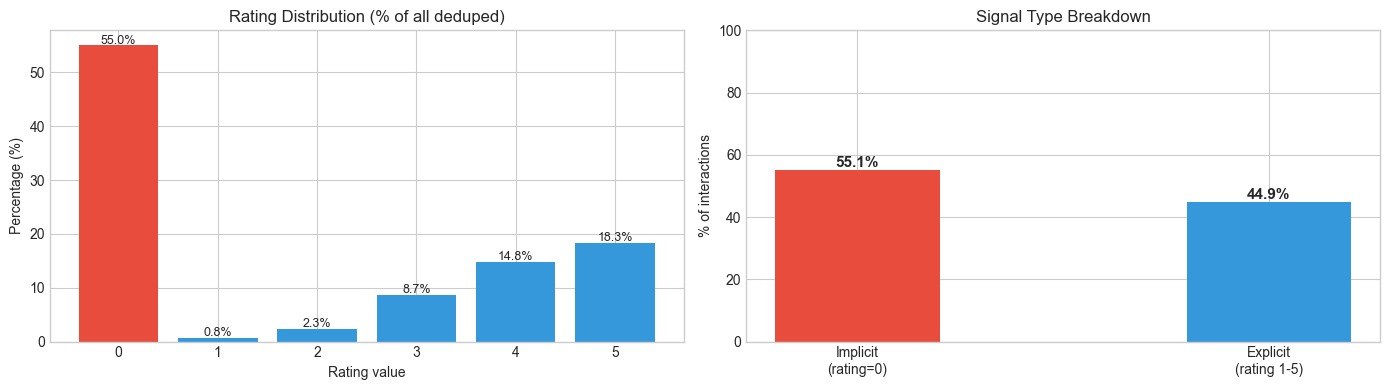


✅ DECISION 1: HYBRID (implicit + explicit)
   Lý do: rating=0 chiếm 55.1% — quá nhiều để bỏ qua


In [16]:
rating_df = pd.Series(rating_ctr).sort_index().to_frame('count')
total_recs = rating_df['count'].sum()
rating_df['pct'] = (rating_df['count'] / total_recs * 100).round(2)

implicit_count = rating_ctr.get(0, 0)
explicit_count = sum(v for k, v in rating_ctr.items() if 1 <= k <= 5)
pct_implicit   = 100.0 * implicit_count / total_recs
pct_explicit   = 100.0 * explicit_count / total_recs

print('── Rating Distribution ──────────────────────────')
display(rating_df)
print(f'\n% rating=0 (implicit) : {pct_implicit:.1f}%')
print(f'% rating 1-5 (explicit): {pct_explicit:.1f}%')

print('\n── is_read distribution ──')
display(pd.Series(is_read_ctr).rename(index={True:'is_read=True', False:'is_read=False'}).to_frame('count'))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(rating_df.index.astype(str), rating_df['pct'],
            color=['#e74c3c' if r == 0 else '#3498db' for r in rating_df.index])
axes[0].set_title('Rating Distribution (% of all deduped)')
axes[0].set_xlabel('Rating value')
axes[0].set_ylabel('Percentage (%)')
for i, (idx, row) in enumerate(rating_df.iterrows()):
    axes[0].text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%", ha='center', fontsize=9)

labels  = ['Implicit\n(rating=0)', 'Explicit\n(rating 1-5)']
values  = [pct_implicit, pct_explicit]
colors  = ['#e74c3c', '#3498db']
axes[1].bar(labels, values, color=colors, width=0.4)
axes[1].set_title('Signal Type Breakdown')
axes[1].set_ylabel('% of interactions')
axes[1].set_ylim(0, 100)
for i, v in enumerate(values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig(HIST_DIR / 'rating_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

# ── Decision ─────────────────────────────────────────────────────────────
if pct_implicit >= 40:
    d1 = 'HYBRID (implicit + explicit)'
    d1_reason = f'rating=0 chiếm {pct_implicit:.1f}% — quá nhiều để bỏ qua'
elif pct_implicit >= 20:
    d1 = 'HYBRID (cân nhắc)'
    d1_reason = f'rating=0 chiếm {pct_implicit:.1f}% — nên kết hợp'
else:
    d1 = 'EXPLICIT (rating 1-5)'
    d1_reason = f'rating=0 chỉ {pct_implicit:.1f}% — explicit đủ mạnh'

print(f'\n✅ DECISION 1: {d1}')
print(f'   Lý do: {d1_reason}')

---
## DECISION 2 — User Activity → Có filter user không?

User ít interaction → cold-start problem → tăng sparsity, giảm chất lượng model.

**Metric cần xem:**
- `median`, `mean` interactions/user
- `% user < 5 interactions`
- Histogram long-tail + log-log

Mode: date_added (year>=2007)
Total unique users: 377,797
Mean    : 7.2
Median  : 3
Std     : 23.1
Max     : 2,924
% users < 5  interactions: 66.5%
% users < 10 interactions: 83.1%
% users < 20 interactions: 92.7%



,percentile,interactions
0,1,1
1,5,1
2,10,1
3,25,1
4,50,3
5,75,6
6,90,15
7,95,26
8,99,72
9,100,2924


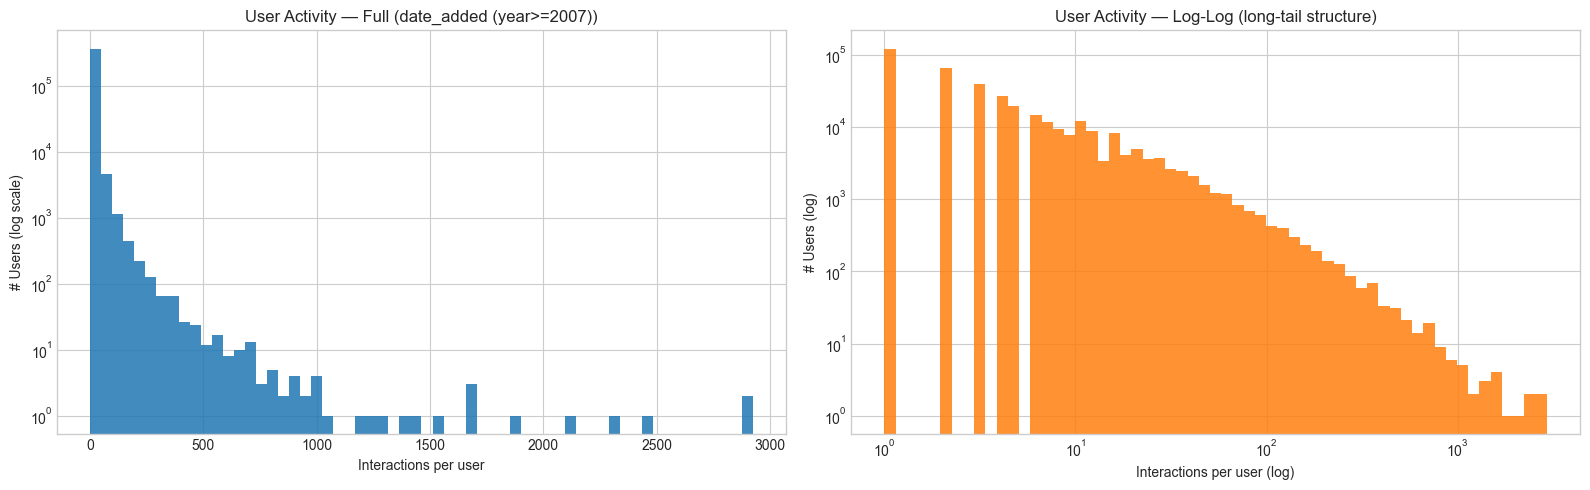

In [17]:
# ── Descriptive stats ───────────────────────────────────────────────────
deg_series = pd.Series(degrees)
percentile_table = pd.DataFrame({
    'percentile': [1, 5, 10, 25, 50, 75, 90, 95, 99, 100],
    'interactions': [int(np.percentile(degrees, p)) for p in [1,5,10,25,50,75,90,95,99,100]],
})

lt5_pct  = float((degrees < 5).mean()  * 100)
lt10_pct = float((degrees < 10).mean() * 100)
lt20_pct = float((degrees < 20).mean() * 100)

print(f'Mode: {mode_label}')
print(f'Total unique users: {len(degrees):,}')
print(f'Mean    : {degrees.mean():.1f}')
print(f'Median  : {np.median(degrees):.0f}')
print(f'Std     : {degrees.std():.1f}')
print(f'Max     : {degrees.max():,}')
print(f'% users < 5  interactions: {lt5_pct:.1f}%')
print(f'% users < 10 interactions: {lt10_pct:.1f}%')
print(f'% users < 20 interactions: {lt20_pct:.1f}%')
print()
display(percentile_table)

# ── Histograms ────────────────────────────────────────────────────────────
p99 = int(np.percentile(degrees, 99))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(degrees, bins=60, color='#1f77b4', alpha=0.85, log=True)
axes[0].set_title(f'User Activity — Full ({mode_label})')
axes[0].set_xlabel('Interactions per user')
axes[0].set_ylabel('# Users (log scale)')

log_bins = np.logspace(np.log10(max(1, degrees.min())), np.log10(degrees.max()), 60)
axes[1].hist(degrees, bins=log_bins, color='#ff7f0e', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('User Activity — Log-Log (long-tail structure)')
axes[1].set_xlabel('Interactions per user (log)')
axes[1].set_ylabel('# Users (log)')

plt.tight_layout()
fig.savefig(HIST_DIR / 'user_activity_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

### Threshold Diagnostics — Coverage Table + Elbow

Đánh giá các candidate threshold để chọn `min_user_interaction` tối ưu.

In [18]:
candidate_thresholds = [3, 5, 6, 7, 8, 10, 15, 20]

# Second streaming pass: count kept interactions + retained items per k
kept_interactions_by_k = {k: 0 for k in candidate_thresholds}
retained_books_by_k    = {k: set() for k in candidate_thresholds}
seen_eval = set()

with INTERACTIONS_PATH.open('r', encoding='utf-8') as f:
    for line_no, raw_line in enumerate(f, 1):
        if MAX_INTERACTION_LINES and line_no > MAX_INTERACTION_LINES:
            break
        line = raw_line.strip()
        if not line: continue
        try: rec = json.loads(line)
        except json.JSONDecodeError: continue
        uid = str(rec.get('user_id', '')).strip()
        bid = str(rec.get('book_id', '')).strip()
        if not uid or not bid: continue
        if DEDUP_INTERACTIONS:
            key = (uid, bid)
            if key in seen_eval: continue
            seen_eval.add(key)
        try: rating = int(rec.get('rating', 0))
        except: rating = 0
        if not in_threshold_mode(rec, rating): continue
        udeg = user_degree.get(uid, 0)
        for k in candidate_thresholds:
            if udeg >= k:
                kept_interactions_by_k[k] += 1
                retained_books_by_k[k].add(bid)
            else:
                break

total_users        = len(degrees)
total_interactions = int(degrees.sum())
total_items        = len(book_degree)

cov_rows = []
for k in candidate_thresholds:
    ku = int((degrees >= k).sum())
    ki = int(kept_interactions_by_k[k])
    ri = len(retained_books_by_k[k])
    du = 100.0 * ku / total_users if total_users else 0
    di = 100.0 * ki / total_interactions if total_interactions else 0
    dens = ki / (ku * ri) if ku * ri else 0
    cov_rows.append({
        'threshold_k': k,
        'kept_users': ku,  'kept_users_pct': round(du, 2),
        'kept_interactions': ki,  'kept_int_pct': round(di, 2),
        'retained_items': ri,
        'density': round(dens, 6),
        'sparsity': round(1 - dens, 6),
    })

coverage_table = pd.DataFrame(cov_rows)
display(coverage_table)

# Save
coverage_table.to_csv(OUTPUT_DIR / 'eda_coverage_table.csv', index=False, encoding='utf-8-sig')

,threshold_k,kept_users,kept_users_pct,kept_interactions,kept_int_pct,retained_items,density,sparsity
0,3,191909,50.8000,2482575,90.8000,36326,0.0004,0.9996
1,5,126695,33.5400,2260514,82.6800,36130,0.0005,0.9995
2,6,107118,28.3500,2162629,79.1000,36045,0.0006,0.9994
3,7,92388,24.4500,2074249,75.8600,35945,0.0006,0.9994
4,8,80693,21.3600,1992384,72.8700,35832,0.0007,0.9993
5,10,63712,16.8600,1848809,67.6200,35626,0.0008,0.9992
6,15,39621,10.4900,1567548,57.3300,35134,0.0011,0.9989
7,20,27486,7.2800,1363978,49.8900,34665,0.0014,0.9986


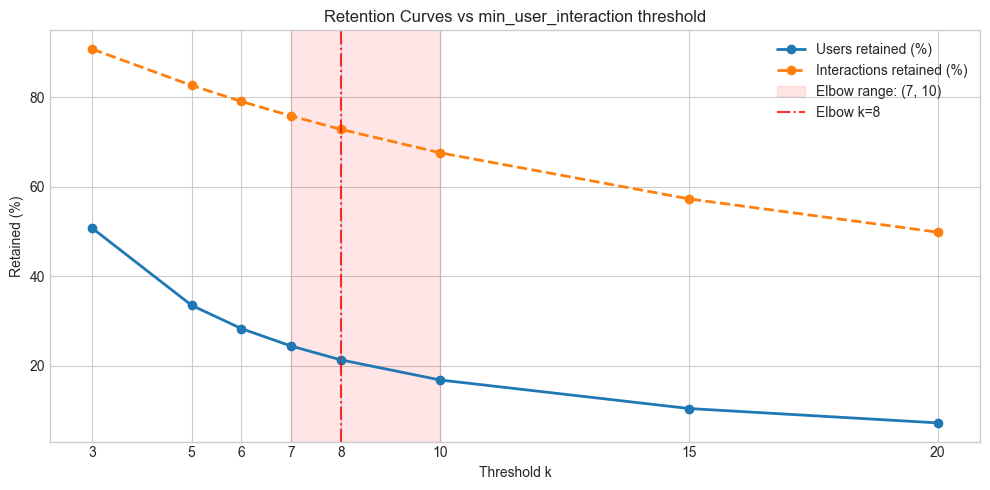

,method,recommended_k,why
0,elbow_range,"(7, 10)",Kneedle on retention curve
1,sparsity_filter,"[7, 8, 10]",Keep k with sparsity <= Q3 (0.999343)
2,tradeoff_final,8,50% interaction + 35% density + 15% user reten...



✅ DECISION 2: min_user_interaction = 8


In [19]:
k_values   = np.array(candidate_thresholds, dtype=np.int32)
users_pct  = coverage_table['kept_users_pct'].values
inter_pct  = coverage_table['kept_int_pct'].values

# Kneedle elbow on user-retention curve
x_span = float(k_values.max() - k_values.min())
x_norm = (k_values - k_values.min()) / x_span if x_span else np.zeros(len(k_values))
y_norm = (users_pct - users_pct.min()) / (users_pct.max() - users_pct.min() + 1e-9)
kneedle_dist = (1 - x_norm) - y_norm
elbow_idx    = int(np.argmax(kneedle_dist))
elbow_k      = int(k_values[elbow_idx])
elbow_range  = (int(k_values[max(0, elbow_idx-1)]), int(k_values[min(len(k_values)-1, elbow_idx+1)]))

fig = plt.figure(figsize=(10, 5))
plt.plot(k_values, users_pct, 'o-', label='Users retained (%)', lw=2)
plt.plot(k_values, inter_pct, 'o--', label='Interactions retained (%)', lw=2)
plt.axvspan(elbow_range[0], elbow_range[1], color='red', alpha=0.1, label=f'Elbow range: {elbow_range}')
plt.axvline(x=elbow_k, color='red', linestyle='-.', alpha=0.8, label=f'Elbow k={elbow_k}')
plt.title('Retention Curves vs min_user_interaction threshold')
plt.xlabel('Threshold k')
plt.ylabel('Retained (%)')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
fig.savefig(HIST_DIR / 'retention_curves.png', dpi=160, bbox_inches='tight')
plt.show()

# ── 3-step threshold selection ────────────────────────────────────────────
# Step 1: Elbow range
elbow_set = set(int(v) for v in k_values[max(0,elbow_idx-1):elbow_idx+2])
# Step 2: Sparsity filter (keep best-density candidates in elbow range)
er = coverage_table[coverage_table['threshold_k'].isin(elbow_set)].copy()
if len(er) == 0: er = coverage_table.copy()
sparsity_cut = float(er['sparsity'].quantile(0.75))
sf = er[er['sparsity'] <= sparsity_cut]
if len(sf) == 0: sf = er.sort_values('density', ascending=False).head(2)
# Step 3: Tradeoff score
sf = sf.copy()
def mm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
sf['score'] = 0.50 * mm(sf['kept_int_pct']) + 0.35 * mm(sf['density']) + 0.15 * mm(sf['kept_users_pct'])
best_row = sf.sort_values('score', ascending=False).iloc[0]
min_user_interaction = int(best_row['threshold_k'])

threshold_methods = pd.DataFrame([
    {'method': 'elbow_range',    'recommended_k': str(elbow_range),     'why': 'Kneedle on retention curve'},
    {'method': 'sparsity_filter','recommended_k': str(sorted(elbow_set)),'why': f'Keep k with sparsity <= Q3 ({sparsity_cut:.6f})'},
    {'method': 'tradeoff_final', 'recommended_k': min_user_interaction,  'why': '50% interaction + 35% density + 15% user retention'},
])
display(threshold_methods)
print(f'\n✅ DECISION 2: min_user_interaction = {min_user_interaction}')

---
## DECISION 3 — Item Popularity → Có filter item không?

Total unique items: 36,514
Mean    : 74.9
Median  : 12
% items < 5  interactions: 24.9%
% items < 10 interactions: 44.0%


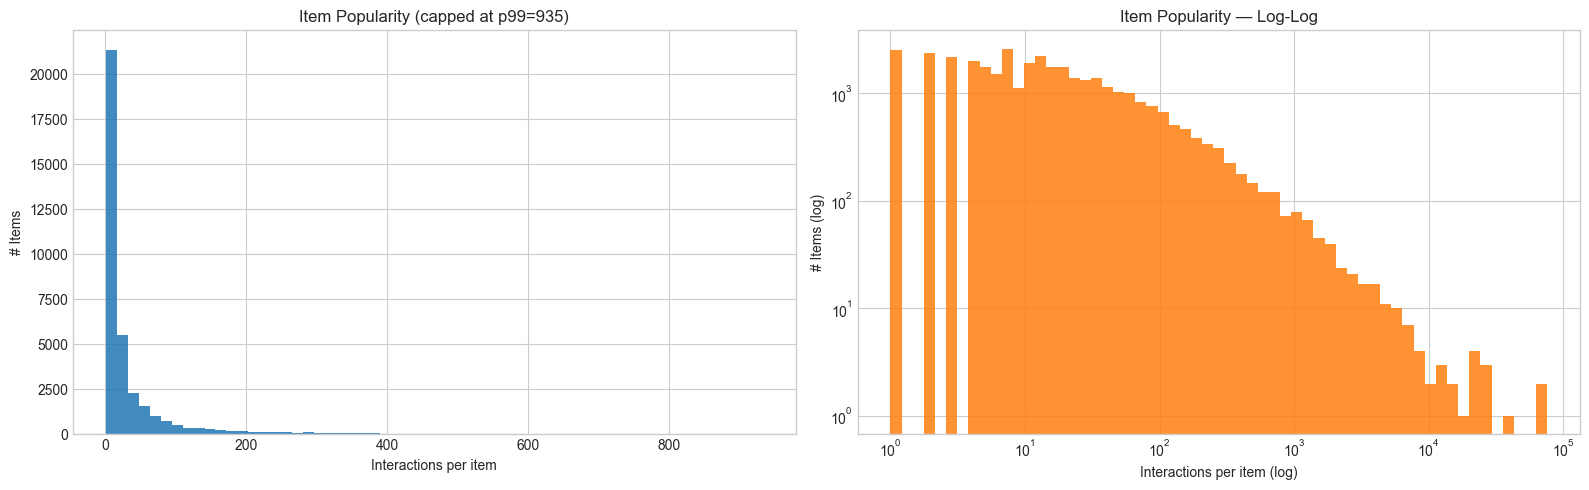

Item elbow k (raw): 9  → snapped to candidates: 8
Long tail exists  : True

✅ DECISION 3: min_item_interaction = 8


,insight,value
0,users_lt5_pct,66.4600
1,users_lt10_pct,83.1400
2,items_lt5_pct,24.8500
3,items_lt10_pct,44.0100
4,user_long_tail,True
5,item_long_tail,True


In [20]:
# Item stats
item_lt5_pct  = float((item_degrees < 5).mean()  * 100)
item_lt10_pct = float((item_degrees < 10).mean() * 100)

print(f'Total unique items: {len(item_degrees):,}')
print(f'Mean    : {item_degrees.mean():.1f}')
print(f'Median  : {np.median(item_degrees):.0f}')
print(f'% items < 5  interactions: {item_lt5_pct:.1f}%')
print(f'% items < 10 interactions: {item_lt10_pct:.1f}%')

item_p99 = int(np.percentile(item_degrees, 99))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(item_degrees[item_degrees <= item_p99], bins=60, color='#1f77b4', alpha=0.85)
axes[0].set_title(f'Item Popularity (capped at p99={item_p99})')
axes[0].set_xlabel('Interactions per item')
axes[0].set_ylabel('# Items')

item_log_bins = np.logspace(np.log10(max(1, item_degrees.min())), np.log10(item_degrees.max()), 60)
axes[1].hist(item_degrees, bins=item_log_bins, color='#ff7f0e', alpha=0.85)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Item Popularity — Log-Log')
axes[1].set_xlabel('Interactions per item (log)')
axes[1].set_ylabel('# Items (log)')

plt.tight_layout()
fig.savefig(HIST_DIR / 'item_popularity_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

# Item threshold selection (elbow method)
item_k_candidates = [3, 5, 8, 10, 15]
item_k_arr = np.arange(1, 21)
items_ret_pct = [100.0 * (item_degrees >= k).sum() / len(item_degrees) for k in item_k_arr]
x_it = (item_k_arr - item_k_arr.min()) / (item_k_arr.max() - item_k_arr.min())
y_it = np.array(items_ret_pct)
y_it_n = (y_it - y_it.min()) / (y_it.max() - y_it.min() + 1e-9)
item_elbow_k = int(item_k_arr[np.argmax((1 - x_it) - y_it_n)])
min_item_interaction = int(min(item_k_candidates, key=lambda x: abs(x - item_elbow_k)))

# Distribution insight
item_long_tail = bool(item_p99 > 10)
print(f'Item elbow k (raw): {item_elbow_k}  → snapped to candidates: {min_item_interaction}')
print(f'Long tail exists  : {item_long_tail}')
print(f'\n✅ DECISION 3: min_item_interaction = {min_item_interaction}')

distribution_insights = pd.DataFrame([
    {'insight': 'users_lt5_pct',       'value': round(lt5_pct, 2)},
    {'insight': 'users_lt10_pct',       'value': round(lt10_pct, 2)},
    {'insight': 'items_lt5_pct',        'value': round(item_lt5_pct, 2)},
    {'insight': 'items_lt10_pct',       'value': round(item_lt10_pct, 2)},
    {'insight': 'user_long_tail',       'value': bool(int(np.percentile(degrees, 99)) > 10)},
    {'insight': 'item_long_tail',       'value': item_long_tail},
])
display(distribution_insights)

---
## DECISION 4 — Time Distribution → Time-Based Split?

Nếu data skew nặng theo thời gian → **bắt buộc dùng time-based split**
để tránh data leakage (future → past).

**Rule:** Nếu 70%+ interactions tập trung trong 3 năm gần nhất → time-based split.

,year,interactions,pct,cumulative_pct
0,2007,44223,1.6200,1.6200
1,2008,71169,2.6000,4.2200
2,2009,78881,2.8800,7.1000
3,2010,91300,3.3400,10.4400
4,2011,163445,5.9800,16.4200
5,2012,305325,11.1700,27.5900
6,2013,369448,13.5100,41.1000
7,2014,362272,13.2500,54.3500
8,2015,374946,13.7100,68.0600
9,2016,470409,17.2000,85.2600


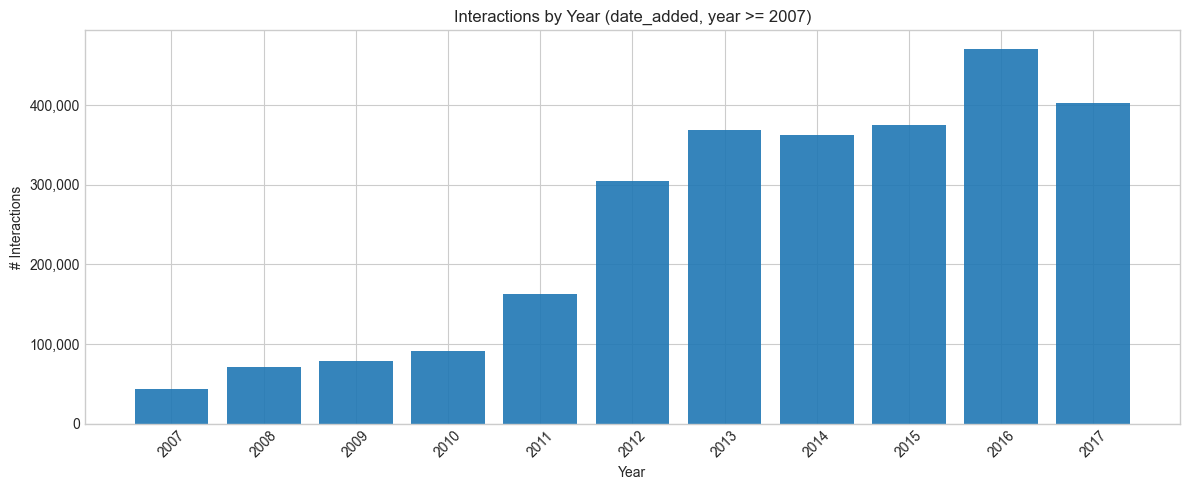

Year range: 2007 - 2017  (span: 11 years)
% interactions in last 3 years: 45.6%

✅ DECISION 4: RANDOM SPLIT (chấp nhận được)
   Lý do: Data phân bố tương đối đều qua các năm (45.6% trong 3 năm cuối)


In [21]:
# Sử dụng year_ctr_filt (đã qua MIN_YEAR filter)
if not year_ctr_filt:
    print('Không có dữ liệu year — kiểm tra date_added format')
else:
    years   = sorted(year_ctr_filt.keys())
    y_counts = [year_ctr_filt[y] for y in years]
    year_df  = pd.DataFrame({'year': years, 'interactions': y_counts})
    year_df['pct'] = (year_df['interactions'] / year_df['interactions'].sum() * 100).round(2)
    year_df['cumulative_pct'] = year_df['pct'].cumsum().round(2)

    display(year_df)

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(years, y_counts, color='#1f77b4', alpha=0.9)
    ax.set_title(f'Interactions by Year (date_added, year >= {MIN_INTERACTION_YEAR})')
    ax.set_xlabel('Year')
    ax.set_ylabel('# Interactions')
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    fig.savefig(HIST_DIR / 'interactions_by_year.png', dpi=160, bbox_inches='tight')
    plt.show()

    # Skewness check: % in last 3 years
    max_year = max(years)
    last3_pct = year_df[year_df['year'] >= max_year - 2]['pct'].sum()
    total_span = max_year - min(years) + 1

    print(f'Year range: {min(years)} - {max_year}  (span: {total_span} years)')
    print(f'% interactions in last 3 years: {last3_pct:.1f}%')

    if last3_pct >= 70:
        d4 = 'TIME-BASED SPLIT (bắt buộc)'
        d4_reason = f'{last3_pct:.1f}% data tập trung trong 3 năm gần nhất'
    elif last3_pct >= 50:
        d4 = 'TIME-BASED SPLIT (khuyến nghị)'
        d4_reason = f'{last3_pct:.1f}% data lệch về những năm gần đây'
    else:
        d4 = 'RANDOM SPLIT (chấp nhận được)'
        d4_reason = f'Data phân bố tương đối đều qua các năm ({last3_pct:.1f}% trong 3 năm cuối)'

    print(f'\n✅ DECISION 4: {d4}')
    print(f'   Lý do: {d4_reason}')

---
## DECISION 5 — Genres Distribution → Top-k = 3 hay 5?

Đọc từ `books.json`:
1. Thử field `genres` (list/dict trực tiếp)
2. Nếu không có → extract từ `popular_shelves` (lọc bỏ non-genre shelves)

**Rule quyết định:**
- Nếu avg genres/book ≥ 5 → có thể dùng **top-5**
- Nếu avg genres/book < 3 → nên dùng **top-3** hoặc full

## PASS 2 — Stream Books Metadata

In [22]:
genre_ctr          = Counter()   # genre name → count across all books
genres_per_book    = []          # number of genres per book
language_ctr       = Counter()
publication_years  = []
avg_ratings_list   = []
book_ids_meta      = set()
book_rows = 0
book_parse_errors  = 0
books_no_genres    = 0

with BOOKS_PATH.open('r', encoding='utf-8') as f:
    for line_no, raw_line in enumerate(f, 1):
        if MAX_BOOK_LINES and line_no > MAX_BOOK_LINES:
            break
        line = raw_line.strip()
        if not line: continue
        try: rec = json.loads(line)
        except json.JSONDecodeError:
            book_parse_errors += 1
            continue

        book_rows += 1
        bid = str(rec.get('book_id', '')).strip()
        if bid: book_ids_meta.add(bid)

        # ── Language ─────────────────────────────────────────────────────
        lang = str(rec.get('language_code', '') or 'unknown').strip() or 'unknown'
        language_ctr[lang] += 1

        # ── Publication year ─────────────────────────────────────────────
        try:
            py = int(rec.get('publication_year') or 0)
            if 1000 <= py <= 2100: publication_years.append(py)
        except: pass

        # ── Average rating ────────────────────────────────────────────────
        try:
            ar = float(rec.get('average_rating') or 0)
            if 0 < ar <= 5: avg_ratings_list.append(ar)
        except: pass

        # ── Genres extraction ─────────────────────────────────────────────
        # Strategy 1: direct 'genres' field (list or dict)
        raw_genres = rec.get('genres')
        book_genre_list = []

        if raw_genres:
            if isinstance(raw_genres, list):
                book_genre_list = [str(g).strip() for g in raw_genres if str(g).strip()]
            elif isinstance(raw_genres, dict):
                # Goodreads genre dict: {genre: count}
                book_genre_list = [k.strip() for k in raw_genres.keys() if k.strip()]
            elif isinstance(raw_genres, str) and raw_genres.strip():
                book_genre_list = [raw_genres.strip()]

        # Strategy 2: fallback to popular_shelves (filter non-genre)
        if not book_genre_list:
            shelves = rec.get('popular_shelves', []) or []
            for sh in shelves:
                name = str(sh.get('name', '') if isinstance(sh, dict) else sh).strip().lower()
                if name and name not in NON_GENRE_SHELVES and len(name) > 2:
                    # Skip purely numeric or very generic names
                    if not name.replace('-','').isdigit():
                        book_genre_list.append(name)

        if book_genre_list:
            for g in book_genre_list:
                genre_ctr[g] += 1
            genres_per_book.append(len(book_genre_list))
        else:
            books_no_genres += 1

book_id_overlap = len(book_ids_meta.intersection(set(str(b) for b in book_degree.keys())))
books_summary = {
    'book_rows': book_rows,
    'parse_errors': book_parse_errors,
    'book_ids_in_metadata': len(book_ids_meta),
    'book_ids_in_interactions': len(book_degree),
    'book_id_overlap': book_id_overlap,
    'books_with_genres': book_rows - books_no_genres,
    'books_no_genres': books_no_genres,
}
print('── Books metadata summary ──')
for k, v in books_summary.items():
    print(f'  {k}: {v:,}' if isinstance(v, int) else f'  {k}: {v}')

── Books metadata summary ──
  book_rows: 36,514
  parse_errors: 0
  book_ids_in_metadata: 36,514
  book_ids_in_interactions: 36,514
  book_id_overlap: 36,514
  books_with_genres: 36,514
  books_no_genres: 0


Total unique genres : 118,891
Avg genres/book     : 42.64
Median genres/book  : 28.0
% books with 0 genre: 0.0%

── Top 30 genres ──


,book_count,pct
poetry,36210,99.1700
fiction,12699,34.7800
literature,11526,31.5700
to-buy,10285,28.1700
classics,10279,28.1500
non-fiction,9986,27.3500
poems,9062,24.8200
my-library,8090,22.1600
favourites,7416,20.3100
classic,6881,18.8400


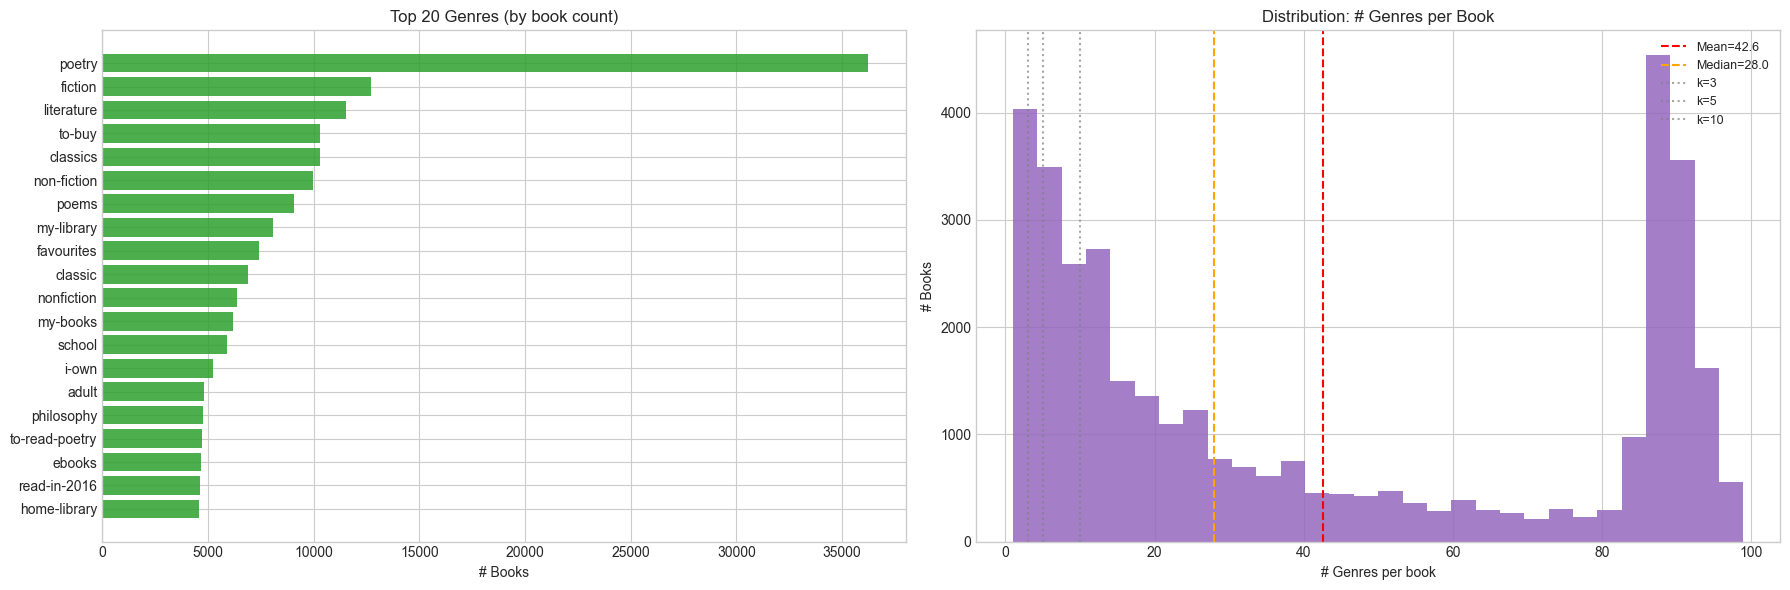

── Top-k genre coverage analysis ──


,top_k,genres_covered,top_genre_names
0,3,3,"poetry, fiction, literature"
1,5,5,"poetry, fiction, literature, to-buy, classics"
2,10,10,"poetry, fiction, literature, to-buy, classics"



✅ DECISION 5: Genres top-k = 5
   Lý do: avg genres/book = 42.64 — đủ để dùng top-5


In [23]:
genres_per_book_arr = np.array(genres_per_book, dtype=np.int32) if genres_per_book else np.array([0])
avg_genres = float(genres_per_book_arr.mean())
median_genres = float(np.median(genres_per_book_arr))

top_genres_df = pd.Series(genre_ctr).sort_values(ascending=False).head(30).to_frame('book_count')
top_genres_df['pct'] = (top_genres_df['book_count'] / book_rows * 100).round(2)

print(f'Total unique genres : {len(genre_ctr):,}')
print(f'Avg genres/book     : {avg_genres:.2f}')
print(f'Median genres/book  : {median_genres:.1f}')
print(f'% books with 0 genre: {100*books_no_genres/book_rows:.1f}%')
print()
print('── Top 30 genres ──')
display(top_genres_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 genres bar
top20 = top_genres_df.head(20)
axes[0].barh(top20.index[::-1], top20['book_count'][::-1], color='#2ca02c', alpha=0.85)
axes[0].set_title('Top 20 Genres (by book count)')
axes[0].set_xlabel('# Books')

# Genres per book histogram
axes[1].hist(genres_per_book_arr, bins=min(30, int(genres_per_book_arr.max())+1),
             color='#9467bd', alpha=0.85)
axes[1].axvline(avg_genres, color='red', linestyle='--', label=f'Mean={avg_genres:.1f}')
axes[1].axvline(median_genres, color='orange', linestyle='--', label=f'Median={median_genres:.1f}')
for k in GENRES_TOP_K_CANDIDATES:
    axes[1].axvline(k, color='gray', linestyle=':', alpha=0.7, label=f'k={k}')
axes[1].set_title('Distribution: # Genres per Book')
axes[1].set_xlabel('# Genres per book')
axes[1].set_ylabel('# Books')
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(HIST_DIR / 'genres_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

# Top-k coverage analysis
print('── Top-k genre coverage analysis ──')
topk_rows = []
for k in GENRES_TOP_K_CANDIDATES:
    topk_genres = set(list(genre_ctr.keys())[:k])  # already sorted by count
    topk_genres = {g for g, _ in genre_ctr.most_common(k)}
    pct_covered  = 100.0 * (genres_per_book_arr >= 1).sum() / len(genres_per_book_arr)  # books with >=1 genre
    books_with_topk = sum(1 for gpb in genres_per_book if gpb >= 1)  # simplified
    topk_rows.append({'top_k': k, 'genres_covered': k, 'top_genre_names': ', '.join(list(genre_ctr.most_common(k))[i][0] for i in range(min(k,5)))})

topk_df = pd.DataFrame(topk_rows)
display(topk_df)

# ── Decision ─────────────────────────────────────────────────────────────
if avg_genres >= 5:
    d5 = 'top-k = 5'
    d5_reason = f'avg genres/book = {avg_genres:.2f} — đủ để dùng top-5'
elif avg_genres >= 3:
    d5 = 'top-k = 3'
    d5_reason = f'avg genres/book = {avg_genres:.2f} — top-3 là an toàn'
else:
    d5 = 'full genres (không cắt)'
    d5_reason = f'avg genres/book = {avg_genres:.2f} — quá ít, giữ hết'

print(f'\n✅ DECISION 5: Genres {d5}')
print(f'   Lý do: {d5_reason}')

---
## Sparsity Overview (before thresholding)

So sánh density của 3 mode để confirm lựa chọn implicit/explicit/hybrid.

In [24]:
def density_sparsity(n_u, n_i, n_e):
    d = n_e / (n_u * n_i) if n_u * n_i else 0.0
    return round(d, 8), round(1 - d, 8)

d_all, s_all = density_sparsity(len(user_deg_all), len(book_deg_all), rows_deduped)
d_exp, s_exp = density_sparsity(len(user_deg_exp), len(book_deg_exp), rows_explicit)
d_da,  s_da  = density_sparsity(len(user_deg_da),  len(book_deg_da),  rows_date_added)

sparsity_overview = pd.DataFrame([
    {'matrix': 'all_dedup',      'users': len(user_deg_all), 'items': len(book_deg_all), 'interactions': rows_deduped,    'density': d_all, 'sparsity': s_all},
    {'matrix': 'explicit_dedup', 'users': len(user_deg_exp), 'items': len(book_deg_exp), 'interactions': rows_explicit,   'density': d_exp, 'sparsity': s_exp},
    {'matrix': 'date_added',     'users': len(user_deg_da),  'items': len(book_deg_da),  'interactions': rows_date_added, 'density': d_da,  'sparsity': s_da},
])
display(sparsity_overview)
sparsity_overview.to_csv(OUTPUT_DIR / 'eda_sparsity_overview.csv', index=False, encoding='utf-8-sig')

,matrix,users,items,interactions,density,sparsity
0,all_dedup,377799,36514,2734350,0.0002,0.9998
1,explicit_dedup,267821,36182,1229059,0.0001,0.9999
2,date_added,377797,36514,2734204,0.0002,0.9998


---
## Final: k-core Filtering + Before/After Stats

Áp dụng `min_user_interaction` và `min_item_interaction` đã chọn.
Tính density/sparsity trước và sau filtering.

In [25]:
# ── k-core iterative filtering ───────────────────────────────────────────
removed_users = set()
removed_items = set()
kcore_log = []

def iter_mode_edges():
    seen = set()
    with INTERACTIONS_PATH.open('r', encoding='utf-8') as fin:
        for line_no, raw_line in enumerate(fin, 1):
            if MAX_INTERACTION_LINES and line_no > MAX_INTERACTION_LINES: break
            line = raw_line.strip()
            if not line: continue
            try: rec = json.loads(line)
            except: continue
            uid = str(rec.get('user_id', '')).strip()
            bid = str(rec.get('book_id', '')).strip()
            if not uid or not bid: continue
            if DEDUP_INTERACTIONS:
                key = (uid, bid)
                if key in seen: continue
                seen.add(key)
            try: rating = int(rec.get('rating', 0))
            except: rating = 0
            if not in_threshold_mode(rec, rating): continue
            yield uid, bid

for it in range(1, 51):
    ud_iter = Counter()
    id_iter = Counter()
    ec_iter = 0
    for uid, bid in iter_mode_edges():
        if uid in removed_users or bid in removed_items: continue
        ud_iter[uid] += 1
        id_iter[bid] += 1
        ec_iter += 1
    low_u = {u for u, d in ud_iter.items() if d < min_user_interaction}
    low_i = {i for i, d in id_iter.items() if d < min_item_interaction}
    kcore_log.append({'iteration': it, 'active_users': len(ud_iter), 'active_items': len(id_iter),
                      'edges': ec_iter, 'removed_users': len(low_u), 'removed_items': len(low_i)})
    if not low_u and not low_i:
        break
    removed_users.update(low_u)
    removed_items.update(low_i)

kcore_log_df = pd.DataFrame(kcore_log)
print(f'k-core converged in {len(kcore_log)} iteration(s)')
display(kcore_log_df)

# Final sets
final_users = set(ud_iter.keys())
final_items = set(id_iter.keys())
final_edges = ec_iter

base_u = len(user_degree); base_i = len(book_degree); base_e = n_interactions_mode
base_d, base_s = density_sparsity(base_u, base_i, base_e)
filt_d, filt_s = density_sparsity(len(final_users), len(final_items), final_edges)

dataset_summary = pd.DataFrame([
    {'stage': 'before_filtering', 'users': base_u, 'items': base_i, 'interactions': base_e, 'density': base_d, 'sparsity': base_s},
    {'stage': 'after_kcore',      'users': len(final_users), 'items': len(final_items), 'interactions': final_edges, 'density': filt_d, 'sparsity': filt_s},
])
print('\n── Dataset Summary (before / after k-core) ──')
display(dataset_summary)

# Learnability
learnability = pd.DataFrame([
    {'metric': 'sparsity',            'before': base_s,  'after': filt_s},
    {'metric': 'cold_user_ratio',     'before': round(lt5_pct/100,4), 'after': 0.0},
    {'metric': 'cold_item_ratio',     'before': round(item_lt5_pct/100,4), 'after': 0.0},
])
display(learnability)

k-core converged in 10 iteration(s)


,iteration,active_users,active_items,edges,removed_users,removed_items
0,1,377797,36514,2734204,297104,13693
1,2,80693,22818,1951727,963,1941
2,3,79730,20877,1934139,507,111
3,4,79223,20766,1929902,40,56
4,5,79183,20710,1929236,25,4
5,6,79158,20706,1929036,2,5
6,7,79156,20701,1928987,1,0
7,8,79155,20701,1928980,0,1
8,9,79155,20700,1928973,2,0
9,10,79153,20700,1928959,0,0



── Dataset Summary (before / after k-core) ──


,stage,users,items,interactions,density,sparsity
0,before_filtering,377797,36514,2734204,0.0002,0.9998
1,after_kcore,79153,20700,1928959,0.0012,0.9988


,metric,before,after
0,sparsity,0.9998,0.9988
1,cold_user_ratio,0.6646,0.0000
2,cold_item_ratio,0.2485,0.0000


---
## Export Filtered Interactions (optional)

Ghi ra file `.json` chứa các interaction đã qua k-core filtering.
Đây là input cho Phase 3.

In [ ]:
if WRITE_FILTERED_FILE:
    out_path = OUTPUT_DIR / f'interactions_filtered_k{min_user_interaction}.json'
    final_u_set = set(final_users)
    final_i_set = set(final_items)
    kept = 0
    seen_export = set()

    with INTERACTIONS_PATH.open('r', encoding='utf-8') as fin, \
         out_path.open('w', encoding='utf-8') as fout:
        for raw_line in fin:
            line = raw_line.strip()
            if not line: continue
            try: rec = json.loads(line)
            except: continue
            uid = str(rec.get('user_id', '')).strip()
            bid = str(rec.get('book_id', '')).strip()
            if not uid or not bid: continue
            if DEDUP_INTERACTIONS:
                key = (uid, bid)
                if key in seen_export: continue
                seen_export.add(key)
            try: rating = int(rec.get('rating', 0))
            except: rating = 0
            if not in_threshold_mode(rec, rating): continue
            if uid in final_u_set and bid in final_i_set:
                fout.write(line + '\n')
                kept += 1

    print(f'Exported {kept:,} interactions → {out_path}')
else:
    print('WRITE_FILTERED_FILE=False — skip export')

---
## ✅ PHASE 2 SUMMARY — 5 Decisions

In [26]:
# Collect all decisions into one summary table
summary_rows = [
    {
        'decision': 1,
        'question': 'Implicit hay Hybrid?',
        'answer': d1,
        'key_metric': f'% rating=0 = {pct_implicit:.1f}%',
    },
    {
        'decision': 2,
        'question': 'Filter user (min_user_interaction)?',
        'answer': f'min_user_interaction = {min_user_interaction}',
        'key_metric': f'% users < {min_user_interaction} interactions = {100*(degrees<min_user_interaction).mean():.1f}%',
    },
    {
        'decision': 3,
        'question': 'Filter item (min_item_interaction)?',
        'answer': f'min_item_interaction = {min_item_interaction}',
        'key_metric': f'% items < {min_item_interaction} interactions = {100*(item_degrees<min_item_interaction).mean():.1f}%',
    },
    {
        'decision': 4,
        'question': 'Time-based split?',
        'answer': d4,
        'key_metric': d4_reason,
    },
    {
        'decision': 5,
        'question': 'Genres top-k?',
        'answer': d5,
        'key_metric': f'avg genres/book = {avg_genres:.2f}',
    },
]

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.max_colwidth', 80)
display(summary_df)

print('\n' + '='*60)
print('PHASE 2 COMPLETE — Paste kết quả này để chốt Phase 3')
print('='*60)
for r in summary_rows:
    print(f"  [{r['decision']}] {r['question']}")
    print(f"      → {r['answer']}")
    print(f"        ({r['key_metric']})")
    print()

,decision,question,answer,key_metric
0,1,Implicit hay Hybrid?,HYBRID (implicit + explicit),% rating=0 = 55.1%
1,2,Filter user (min_user_interaction)?,min_user_interaction = 8,% users < 8 interactions = 78.6%
2,3,Filter item (min_item_interaction)?,min_item_interaction = 8,% items < 8 interactions = 37.5%
3,4,Time-based split?,RANDOM SPLIT (chấp nhận được),Data phân bố tương đối đều qua các năm (45.6% trong 3 năm cuối)
4,5,Genres top-k?,top-k = 5,avg genres/book = 42.64



PHASE 2 COMPLETE — Paste kết quả này để chốt Phase 3
  [1] Implicit hay Hybrid?
      → HYBRID (implicit + explicit)
        (% rating=0 = 55.1%)

  [2] Filter user (min_user_interaction)?
      → min_user_interaction = 8
        (% users < 8 interactions = 78.6%)

  [3] Filter item (min_item_interaction)?
      → min_item_interaction = 8
        (% items < 8 interactions = 37.5%)

  [4] Time-based split?
      → RANDOM SPLIT (chấp nhận được)
        (Data phân bố tương đối đều qua các năm (45.6% trong 3 năm cuối))

  [5] Genres top-k?
      → top-k = 5
        (avg genres/book = 42.64)



In [27]:
from datetime import datetime

def safe_csv(df, path):
    try:
        df.to_csv(path, index=False, encoding='utf-8-sig')
        return path
    except PermissionError:
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        fb = path.with_name(f'{path.stem}_{ts}{path.suffix}')
        df.to_csv(fb, index=False, encoding='utf-8-sig')
        return fb

saved = {
    'sparsity':        safe_csv(sparsity_overview,   OUTPUT_DIR / 'eda_sparsity_overview.csv'),
    'coverage':        safe_csv(coverage_table,      OUTPUT_DIR / 'eda_coverage_table.csv'),
    'percentile':      safe_csv(percentile_table,    OUTPUT_DIR / 'eda_percentile_table.csv'),
    'threshold_methods': safe_csv(threshold_methods, OUTPUT_DIR / 'eda_threshold_methods.csv'),
    'distribution':    safe_csv(distribution_insights, OUTPUT_DIR / 'eda_distribution_insights.csv'),
    'year':            safe_csv(year_df,             OUTPUT_DIR / 'eda_year_distribution.csv'),
    'top_genres':      safe_csv(top_genres_df.reset_index().rename(columns={'index':'genre'}), OUTPUT_DIR / 'eda_genres_top30.csv'),
    'dataset_summary': safe_csv(dataset_summary,     OUTPUT_DIR / 'eda_dataset_summary.csv'),
    'learnability':    safe_csv(learnability,        OUTPUT_DIR / 'eda_learnability.csv'),
    'kcore_log':       safe_csv(kcore_log_df,        OUTPUT_DIR / 'eda_kcore_log.csv'),
    'phase2_decisions': safe_csv(summary_df,         OUTPUT_DIR / 'eda_phase2_decisions.csv'),
}

for name, path in saved.items():
    print(f'  Saved [{name}]: {path}')

final_output = pd.DataFrame([
    {'output': 'Filtered Users',        'value': len(final_users)},
    {'output': 'Filtered Items',        'value': len(final_items)},
    {'output': 'Filtered Interactions', 'value': final_edges},
    {'output': 'Filtered Density',      'value': filt_d},
    {'output': 'min_user_interaction',  'value': min_user_interaction},
    {'output': 'min_item_interaction',  'value': min_item_interaction},
    {'output': 'k_core',               'value': min_user_interaction},
    {'output': 'genres_top_k',         'value': d5},
    {'output': 'use_time_split',       'value': d4},
    {'output': 'interaction_mode',     'value': d1},
])
safe_csv(final_output, OUTPUT_DIR / 'eda_final_output.csv')
display(final_output)

  Saved [sparsity]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_sparsity_overview.csv
  Saved [coverage]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_coverage_table.csv
  Saved [percentile]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_percentile_table.csv
  Saved [threshold_methods]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_threshold_methods.csv
  Saved [distribution]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_distribution_insights.csv
  Saved [year]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_year_distribution.csv
  Saved [top_genres]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_genres_top30.csv
  Saved [dataset_summary]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_dataset_summary.csv
  Saved [learnability]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_learnability.csv
  Saved [kcore_log]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_kcore_log.csv
  Saved [phase2_decisions]: d:\NAM3_UIT\HK2\MXH\Data\eda_outputs\eda_phase2_decisions.csv


,output,value
0,Filtered Users,79153
1,Filtered Items,20700
2,Filtered Interactions,1928959
3,Filtered Density,0.0012
4,min_user_interaction,8
5,min_item_interaction,8
6,k_core,8
7,genres_top_k,top-k = 5
8,use_time_split,RANDOM SPLIT (chấp nhận được)
9,interaction_mode,HYBRID (implicit + explicit)
